# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

#Setting visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [100]:
#Setting display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("=" * 60)
print("AVIATION ACCIDENT DATA ANALYSIS")
print("=" * 60)



AVIATION ACCIDENT DATA ANALYSIS


## Exploratory Data Analysis  
- Load in the cleaned data

In [101]:
import pandas as pd
df= pd.read_csv(r'C:\Users\HP\desktop\dsc-course0-m8-lab\Aviation_Accidents.csv')

C:\Users\HP\AppData\Local\Temp\ipykernel_4468\2352043495.py:2: DtypeWarning: Columns (0: Event.Id, 1: Latitude, 2: Longitude, 3: Broad.phase.of.flight) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv(r'C:\Users\HP\desktop\dsc-course0-m8-lab\Aviation_Accidents.csv')


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [102]:
print(f"\nLoaded cleaned data:")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())



Loaded cleaned data:
Shape: (82805, 37)
Columns: ['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date', 'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code', 'Airport.Name', 'Injury.Severity', 'Aircraft.damage', 'Aircraft.Category', 'Registration.Number', 'Make', 'Model', 'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description', 'Schedule', 'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured', 'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status', 'Publication.Date', 'total_fatal_injuries', 'total_serious_injuries', 'total_minor_injuries', 'total_uninjured', 'make_u', 'make_stage1']

First 5 rows:
         Event.Id Investigation.Type Accident.Number  Event.Date  \
0  20001218X45444           Accident      SEA87LA080  1948-10-24   
1  20001218X45447           Accident      LAX94LA336  1962-07-19   
2  20061025X01555           Accident      NYC07LA005  1974-08-30   
3 

In [103]:
print(f"\nData types:")
print(df.dtypes)


Data types:
Event.Id                   object
Investigation.Type            str
Accident.Number               str
Event.Date                    str
Location                      str
Country                       str
Latitude                   object
Longitude                  object
Airport.Code                  str
Airport.Name                  str
Injury.Severity               str
Aircraft.damage               str
Aircraft.Category             str
Registration.Number           str
Make                          str
Model                         str
Amateur.Built                 str
Number.of.Engines         float64
Engine.Type                   str
FAR.Description               str
Schedule                      str
Purpose.of.flight             str
Air.carrier                   str
Total.Fatal.Injuries      float64
Total.Serious.Injuries    float64
Total.Minor.Injuries      float64
Total.Uninjured           float64
Weather.Condition             str
Broad.phase.of.flight         str
R

In [104]:
print(f"\nMissing values:")
print(df.isnull().sum())


Missing values:
Event.Id                      0
Investigation.Type            0
Accident.Number               0
Event.Date                    0
Location                     23
Country                     218
Latitude                  50651
Longitude                 50660
Airport.Code              33947
Airport.Name              31418
Injury.Severity             279
Aircraft.damage            2022
Aircraft.Category         53975
Registration.Number         158
Make                         14
Model                        39
Amateur.Built                20
Number.of.Engines             0
Engine.Type                3051
FAR.Description           54107
Schedule                  71887
Purpose.of.flight          3244
Air.carrier               67682
Total.Fatal.Injuries      10613
Total.Serious.Injuries    11396
Total.Minor.Injuries      10751
Total.Uninjured            5056
Weather.Condition          1577
Broad.phase.of.flight     22003
Report.Status              3578
Publication.Date       

In [105]:
#Separating small vs Large Aircraft
print("\n" + "=" * 60)
print("SEPARATING SMALL VS LARGE AIRCRAFT")
print("=" * 60)

# Create 'Total_Aboard' column by summing relevant injury columns
# map existing total columns to the expected short names and compute Total_Aboard
df['inj_tot_f'] = df['total_fatal_injuries'].fillna(0)
df['inj_tot_s'] = df['total_serious_injuries'].fillna(0)
df['inj_tot_m'] = df['total_minor_injuries'].fillna(0)
df['inj_tot_n'] = df['total_uninjured'].fillna(0)
df['Total_Aboard'] = df[['inj_tot_f', 'inj_tot_s', 'inj_tot_m', 'inj_tot_n']].sum(axis=1)

# Create missing columns for analysis BEFORE subsetting
df['Injury_Fraction'] = df['inj_tot_f'] / df['Total_Aboard']

#Using passenger threshold of 20
df_small = df[df['Total_Aboard'] <= 20]
df_large = df[df['Total_Aboard'] > 20]

print(f"Small aircraft (<=20 passengers): {len(df_small)} records")
print(f"Large aircraft (>20 passengers): {len(df_large)} records")


SEPARATING SMALL VS LARGE AIRCRAFT
Small aircraft (<=20 passengers): 80629 records
Large aircraft (>20 passengers): 2176 records


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [106]:
#Analyzing makes - injury rates
print("\n" + "=" * 60)
print("ANALYZING MAKES - INJURY RATES")
print("=" * 60)


ANALYZING MAKES - INJURY RATES


In [107]:
#Function that analyzes makes
def analyze_makes(df, size_category):
  """Analyze injury rates by make for a given size category"""

  #Grouping by make and calculating metrics
  make_analysis = df.groupby('acft_make').agg({
      'Injury_Fraction' : ['mean', 'count', 'std', 'median'],
      'Is_Destroyed' : 'mean',
      'Total_Aboard' : 'mean'
  })

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [108]:
#Function that analyzes makes
def analyze_makes(df, size_category):
  """Analyze injury rates by make for a given size category"""

  #Grouping by make and calculating metrics
  make_analysis = df.groupby('acft_make').agg({
      'Injury_Fraction' : ['mean', 'count', 'std', 'median'],
      'Is_Destroyed' : 'mean',
      'Total_Aboard' : 'mean'
  })

  #Flattening column names
  make_analysis.columns = ['mean_injury', 'count', 'std_injury', 'median_injury',
                           'destruction_rate', 'avg_passengers']

  #Filtering to makes with at least 10 records
  make_analysis = make_analysis[make_analysis['count'] >=10]

  #Sorting by injury rate (ascending)
  make_analysis = make_analysis.sort_values('mean_injury')
  return make_analysis



**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [109]:
#VISUALIZATION
print("\n" + "=" * 60)
print("VISUALIZATION: TOP MAKES COMPARISON")
print("=" * 60)




VISUALIZATION: TOP MAKES COMPARISON


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

Large aircraft types with >= 10 records: 50
                                mean_injury  count  std_injury  median_injury
acft_make         Model                                                      
AIRBUS INDUSTRIE  A320-232           0.0000     11      0.0000            0.0
BOEING            727-223            0.0000     16      0.0000            0.0
                  727-200            0.0000     33      0.0000            0.0
                  717-200            0.0000     14      0.0000            0.0
                  757-232            0.0000     22      0.0000            0.0
                  757-223            0.0000     12      0.0000            0.0
                  767                0.0000     24      0.0000            0.0
                  777                0.0000     11      0.0000            0.0
                  757                0.0000     18      0.0000            0.0
                  757-200            0.0000     12      0.0000            0.0
                  74

C:\Users\HP\AppData\Local\Temp\ipykernel_4468\2312836201.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, y='type_label', x='mean_injury', palette='viridis')


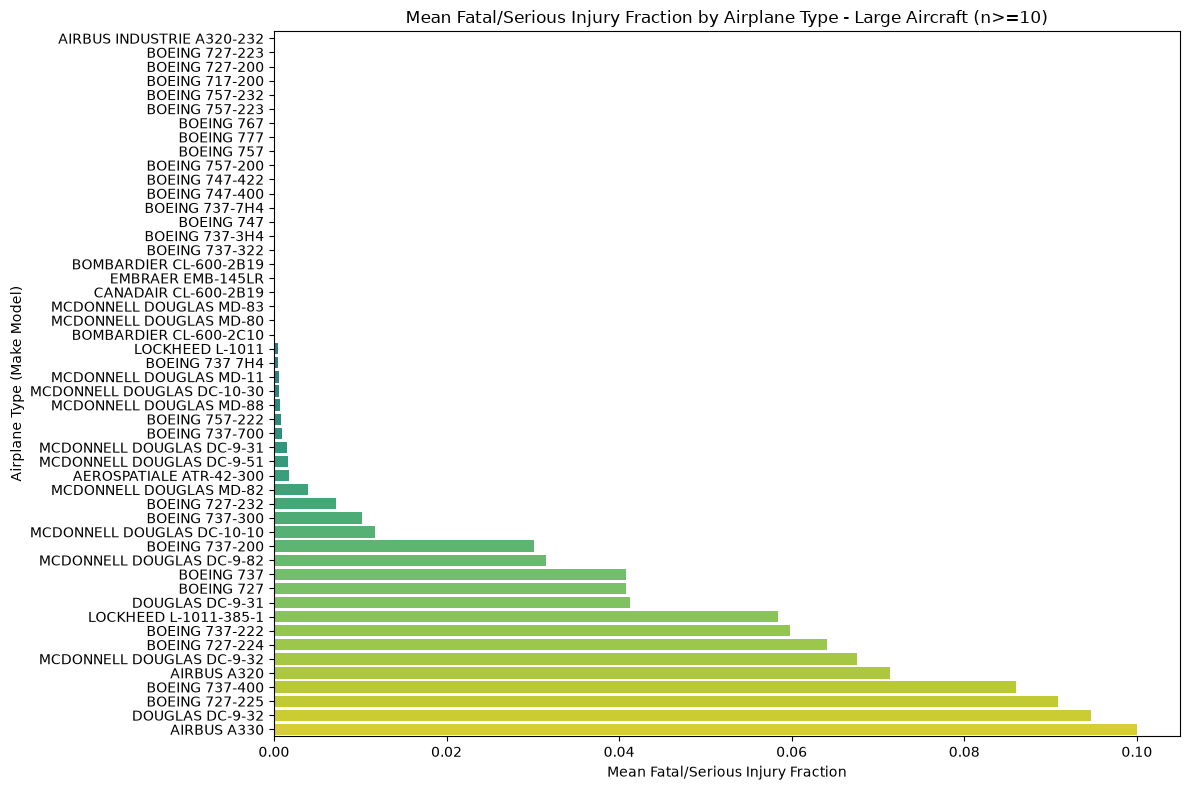

C:\Users\HP\AppData\Local\Temp\ipykernel_4468\2312836201.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_large_valid, y='type_label', x='Injury_Fraction',


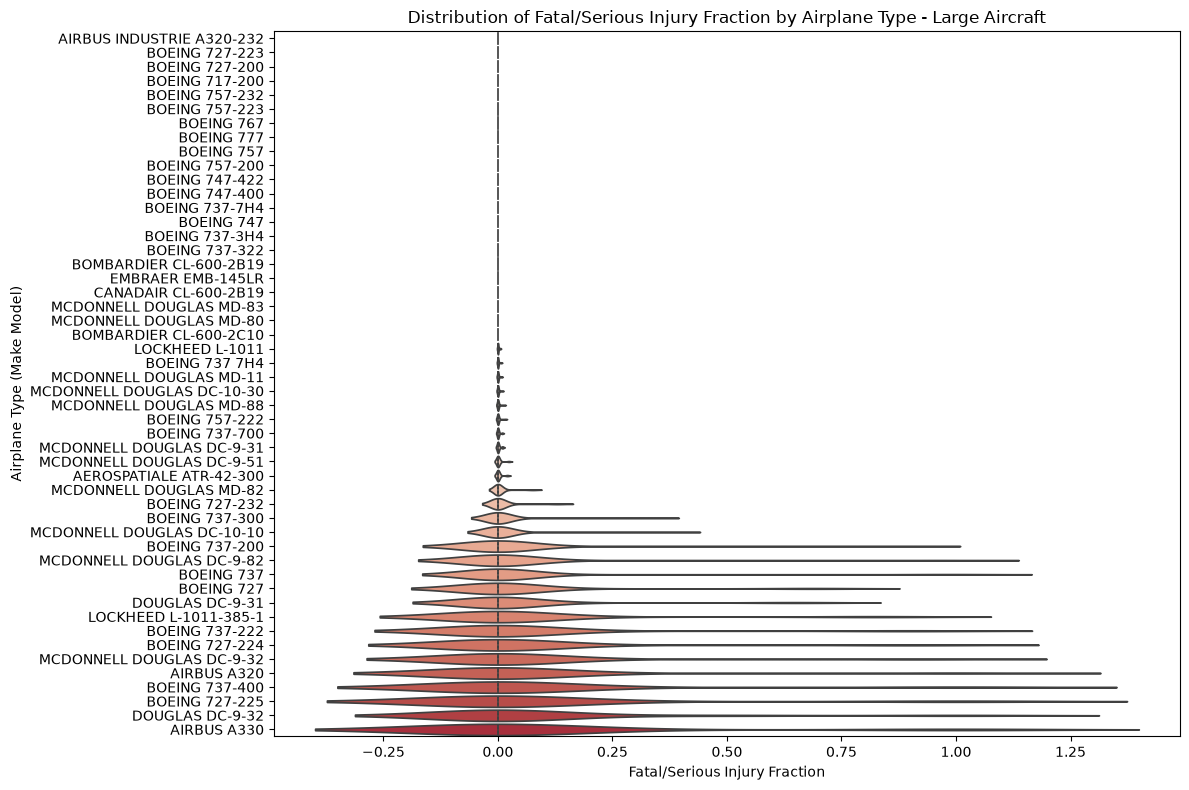

In [110]:
try:
    import seaborn as sns
except ModuleNotFoundError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])
    import seaborn as sns


# Group by airplane type (Make + Model) for large aircraft
# Ensure acft_make exists in df_large
if 'acft_make' not in df_large.columns:
    for alt in ['make_u', 'Make', 'make_stage1']:
        if alt in df_large.columns:
            df_large['acft_make'] = df_large[alt]
            break
    else:
        raise KeyError(f"No aircraft make column found in df_large. Available columns: {df_large.columns.tolist()}")

# Ensure Model column exists
if 'Model' not in df_large.columns:
    if 'model' in df_large.columns:
        df_large['Model'] = df_large['model']
    else:
        raise KeyError(f"No Model column found in df_large. Available columns: {df_large.columns.tolist()}")

# Group by airplane type (Make + Model) for large aircraft
large_type_analysis = (
    df_large.dropna(subset=['Model'])
    .groupby(['acft_make', 'Model'])
    .agg(
        mean_injury=('Injury_Fraction', 'mean'),
        count=('Injury_Fraction', 'count'),
        std_injury=('Injury_Fraction', 'std'),
        median_injury=('Injury_Fraction', 'median')
    )
)

# Filter: at least 10 examples per model/make
large_type_analysis = large_type_analysis[large_type_analysis['count'] >= 10]
large_type_analysis = large_type_analysis.sort_values('mean_injury')

print(f"Large aircraft types with >= 10 records: {len(large_type_analysis)}")
print(large_type_analysis.round(4))

# --- Plot 1: Mean fatal/serious injury fraction (bar plot) ---
plot_data = large_type_analysis.reset_index()
plot_data['type_label'] = plot_data['acft_make'] + ' ' + plot_data['Model']

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib", "seaborn"])
    import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
sns.barplot(data=plot_data, y='type_label', x='mean_injury', palette='viridis')
plt.title('Mean Fatal/Serious Injury Fraction by Airplane Type - Large Aircraft (n>=10)')
plt.xlabel('Mean Fatal/Serious Injury Fraction')
plt.ylabel('Airplane Type (Make Model)')
plt.tight_layout()
plt.show()

# --- Plot 2: Distributional plot (violinplot) ---
valid_types = large_type_analysis.index  # MultiIndex of (acft_make, Model)
df_large_valid = df_large.dropna(subset=['Model']).copy()
df_large_valid['type_key'] = list(zip(df_large_valid['acft_make'], df_large_valid['Model']))
df_large_valid = df_large_valid[df_large_valid['type_key'].isin(valid_types)]
df_large_valid['type_label'] = df_large_valid['acft_make'] + ' ' + df_large_valid['Model']

order = plot_data.sort_values('mean_injury')['type_label'].tolist()

plt.figure(figsize=(12, 8))
sns.violinplot(data=df_large_valid, y='type_label', x='Injury_Fraction',
               order=order, palette='coolwarm', inner='quartile')
plt.title('Distribution of Fatal/Serious Injury Fraction by Airplane Type - Large Aircraft')
plt.xlabel('Fatal/Serious Injury Fraction')
plt.ylabel('Airplane Type (Make Model)')
plt.tight_layout()
plt.show()

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

In [111]:
#Analysis of contributing factors
print("\n" + "=" * 60)
print("ANALYZING CONTRIBUTING FACTORS")
print("=" * 60)

#Weather condition
print("\n" + "=" * 40)
print("FACTOR 1: WEATHER CONDITIONS")
print("-" * 40)

#Checking if weather condition column exists
weather_col = None
possible_weather = ['Weather.Condition', 'Weather Condition', 'WeatherCondition', 'wx_cond_basic']
for col in possible_weather:
  if col in df.columns:
    weather_col = col
    break
if weather_col:
  #Analyzing weather impact
  #Analysis of contributing factors
  print("\n" + "=" * 60)
  print("ANALYZING CONTRIBUTING FACTORS")
  print("=" * 60)

  #Weather condition
  print("\n" + "=" * 40)
  print("FACTOR 1: WEATHER CONDITIONS")
  print("-" * 40)

  #Checking if weather condition column exists
  weather_col = None
  possible_weather = ['Weather.Condition', 'Weather Condition', 'WeatherCondition', 'wx_cond_basic']
  for col in possible_weather:
    if col in df.columns:
      weather_col = col
      break
  if weather_col:
    if 'Is_Destroyed' not in df.columns:
      df['Is_Destroyed'] = df['Aircraft.damage'].fillna('').str.contains('destroy', case=False).astype(int)

    weather_analysis = df.groupby(weather_col).agg({
        'Injury_Fraction': ['mean', 'count', 'std', 'median'],
        'Is_Destroyed' : 'mean'
    })
    weather_analysis.columns = ['mean_injury', 'count', 'std_injury', 'median_injury', 'destruction_rate']

    #Filtering the weather conditions with at least 10 occurrences
    weather_analysis = weather_analysis[weather_analysis['count'] >= 10]
    weather_analysis = weather_analysis.sort_values('mean_injury')

    print("\nWeather Conditions Impact:")
    print(weather_analysis.round(4))
  weather_analysis.columns = ['mean_injury', 'count', 'std_injury', 'median_injury', 'destruction_rate']

  #Filtering the weather conditions with at least 10 occurrences
  weather_analysis = weather_analysis[weather_analysis['count'] >= 10]
  weather_analysis = weather_analysis.sort_values('mean_injury')

  print("\nWeather Conditions Impact:")
  print(weather_analysis.round(4))





ANALYZING CONTRIBUTING FACTORS

FACTOR 1: WEATHER CONDITIONS
----------------------------------------

ANALYZING CONTRIBUTING FACTORS

FACTOR 1: WEATHER CONDITIONS
----------------------------------------

Weather Conditions Impact:
                   mean_injury  count  std_injury  median_injury  \
Weather.Condition                                                  
VMC                     0.1376  74616      0.3342            0.0   
UNK                     0.5360    792      0.4899            1.0   
IMC                     0.5449   5704      0.4855            1.0   

                   destruction_rate  
Weather.Condition                    
VMC                          0.1752  
UNK                          0.5177  
IMC                          0.5564  

Weather Conditions Impact:
                   mean_injury  count  std_injury  median_injury  \
Weather.Condition                                                  
VMC                     0.1376  74616      0.3342            0.0   
UNK

In [112]:
import pandas as pd
#ENGINE TYPE
print("\n" + "=" * 40)
print("FACTOR 3: ENGINE TYPE")
print("-" * 40)

#Checking if engine type column exists
engine_col = None
possible_engine = ['Engine.Type', 'Engine Type', 'EngineType']
for col in possible_engine:
  if col in df.columns:
    engine_col = col
    break
if engine_col:
  #Analyzing engine type impact
  engine_analysis = df.groupby(engine_col).agg({
        'Injury_Fraction': ['mean', 'count', 'std', 'median'],
        'Is_Destroyed': 'mean'
    })
  engine_analysis.columns = ['mean_injury', 'count', 'std_injury', 'median_injury', 'destruction_rate']

  #Filtering to engine types with at least 10 occurrences
  engine_analysis = engine_analysis[engine_analysis['count'] >= 10]
  engine_analysis = engine_analysis.sort_values('mean_injury')

  print("\nEngine Type Impact")
  print(engine_analysis.round(4))
else:
  print("Engine Type Column not found.")


FACTOR 3: ENGINE TYPE
----------------------------------------

Engine Type Impact
               mean_injury  count  std_injury  median_injury  destruction_rate
Engine.Type                                                                   
TURBO FAN           0.0623   2270      0.2340            0.0            0.0777
UNKNOWN             0.1289    738      0.3222            0.0            0.2306
TURBO JET           0.1675    689      0.3658            0.0            0.1986
RECIPROCATING       0.1724  68992      0.3682            0.0            0.2088
TURBO SHAFT         0.1760   3526      0.3579            0.0            0.2441
TURBO PROP          0.2144   3305      0.4011            0.0            0.2357


In [113]:
#Summary statistics and recommendations
print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

#Overall statistics
print("\nOVERALL STATISTICS:")
print(f"Total accidents analyzed: {len(df)}")
print(f"Small aircraft accidents: {len(df_small)}")
print(f"Large aircraft accidents: {len(df_large)}")
print(f"\nOverall mean injury fraction: {df['Injury_Fraction'].mean():.4f}")
print(f"Overall mean destruction rate: {df['Is_Destroyed'].mean():.4f}")

print("\nSMALL AIRCRAFT:")
print(f"Mean injury fraction: {df_small['Injury_Fraction'].mean():.4f}")
print(f"Mean destruction rate: {df_small['Is_Destroyed'].mean():.4f}" if 'Is_Destroyed' in df_small.columns else "Is_Destroyed column not found in df_small")

print("\nLARGE AIRCRAFT:")
print(f"Mean injury fraction: {df_large['Injury_Fraction'].mean():.4f}")
if 'Is_Destroyed' in df_large.columns:
    print(f"Mean destruction rate: {df_large['Is_Destroyed'].mean():.4f}")
elif 'Is_Destroyed' in df.columns:
    print(f"Mean destruction rate: {df.loc[df['Total_Aboard'] > 20, 'Is_Destroyed'].mean():.4f}")
else:
    print("Is_Destroyed column not found in df_large or df")


SUMMARY STATISTICS

OVERALL STATISTICS:
Total accidents analyzed: 82805
Small aircraft accidents: 80629
Large aircraft accidents: 2176

Overall mean injury fraction: 0.1733
Overall mean destruction rate: 0.2052

SMALL AIRCRAFT:
Mean injury fraction: 0.1773
Is_Destroyed column not found in df_small

LARGE AIRCRAFT:
Mean injury fraction: 0.0286
Mean destruction rate: 0.0437


In [114]:
#Recommendations
print("\n" + "=" * 60)
print("RECOMMENDATIONS")
print("=" * 60)

print("\n" + "=" * 60)
print("SMALL AIRCRAFT RECOMMENDATIONS (<= 20 passengers)")
print("=" * 60)

#Getting top 5 small makes by injury rate
# ensure the make column used by analyze_makes exists
if 'acft_make' not in df.columns:
    if 'make_u' in df.columns:
        df['acft_make'] = df['make_u']
    elif 'Make' in df.columns:
        df['acft_make'] = df['Make']
    else:
        raise KeyError("No aircraft make column found in dataframe.")

df_small = df.loc[df_small.index].copy()
df_large = df.loc[df_large.index].copy()

small_make_analysis = analyze_makes(df_small, 'small')
large_make_analysis = analyze_makes(df_large, 'large')

small_destruction = small_make_analysis.sort_values('destruction_rate')
large_destruction = large_make_analysis.sort_values('destruction_rate')

top5_small_makes = small_make_analysis.head(5)
print("\nTop 5 Small Makes by Lowest Injury Rate:")
print(top5_small_makes[['mean_injury', 'count', 'destruction_rate']].round(4))

#Getting top 5 small makes by destruction rate
top5_small_destruction = small_destruction.head(5)
print("\nTop 5 Small Makes by Lowest Destruction Rate:")
print(top5_small_destruction[['destruction_rate', 'count']].round(4))

#Finding makes that appear in both top lists (best overall)
best_small_makes = set(top5_small_makes.index) & set(top5_small_destruction.index)
if best_small_makes:
  print(f"\nBEST OVERALL SMALL MAKES (Top 5 in both injury AND destruction):")
  for make in best_small_makes:
    print(f"  - {make}")

print("\n" + "=" * 60)
print("LARGE AIRCRAFT RECOMMENDATIONS (> 20 passengers)")
print("=" * 60)

#Getting top 5 large makes by injury rate
top_large_makes = large_make_analysis.head(5)
print("\nTop 5 Large Makes by Lowest Injury Rate:")
print(top_large_makes[['mean_injury', 'count', 'destruction_rate']].round(4))

#Getting top 5 large makes by destruction rate
top5_large_destruction = large_destruction.head(5)
print("\nTop Large Makes by Lowest Destruction Rate:")
print(top5_large_destruction[['destruction_rate', 'count']].round(4))

#Finding makes that appear in both top lists
best_large_makes = set(top_large_makes.index) & set(top5_large_destruction.index)
if best_large_makes:
  print(f"\nBEST OVERALL LARGE MAKES (Top 5 in both injury AND destruction):")
  for make in best_large_makes:
    print(f"    -{make}")


RECOMMENDATIONS

SMALL AIRCRAFT RECOMMENDATIONS (<= 20 passengers)



Top 5 Small Makes by Lowest Injury Rate:
                          mean_injury  count  destruction_rate
acft_make                                                     
AMERICAN LEGEND AIRCRAFT          0.0     19            0.0000
BARNES                            0.0     13            0.3077
HEAD BALLOONS                     0.0     12            0.1667
POWRACHUTE                        0.0     13            0.0000
LINDSTRAND BALLOONS               0.0     14            0.0000

Top 5 Small Makes by Lowest Destruction Rate:
                          destruction_rate  count
acft_make                                        
AMERICAN LEGEND AIRCRAFT               0.0     19
PROGRESSIVE AERODYNE                   0.0     11
EVEKTOR-AEROTECHNIK AS                 0.0     30
AEROSTAR INTERNATIONAL                 0.0     24
REMOS AIRCRAFT GMBH                    0.0     13

BEST OVERALL SMALL MAKES (Top 5 in both injury AND destruction):
  - AMERICAN LEGEND AIRCRAFT

LARGE AIRCRAFT RECOMMEND

In [115]:
#Recommending specific models
print("\n" + "=" * 60)
print("RECOMMENDED SPECIFIC AIRCRAFT MODELS")
print("=" * 60)

print("\nSMALL AIRCRAFT - Top 10 Models:")
#Recommending specific models
print("\n" + "=" * 60)
print("RECOMMENDED SPECIFIC AIRCRAFT MODELS")
print("=" * 60)

small_models = (
    df_small.dropna(subset=['Model'])
    .groupby(['acft_make', 'Model'])
    .agg(
        mean_injury=('Injury_Fraction', 'mean'),
        count=('Injury_Fraction', 'count'),
        std_injury=('Injury_Fraction', 'std'),
        median_injury=('Injury_Fraction', 'median'),
        destruction_rate=('Is_Destroyed', 'mean')
    )
    .query('count >= 10')
    .sort_values('mean_injury')
)

large_models = (
    df_large.dropna(subset=['Model'])
    .groupby(['acft_make', 'Model'])
    .agg(
        mean_injury=('Injury_Fraction', 'mean'),
        count=('Injury_Fraction', 'count'),
        std_injury=('Injury_Fraction', 'std'),
        median_injury=('Injury_Fraction', 'median'),
        destruction_rate=('Is_Destroyed', 'mean')
    )
    .query('count >= 10')
    .sort_values('mean_injury')
)

print("\nSMALL AIRCRAFT - Top 10 Models:")
print(small_models.head(10)[['mean_injury', 'count', 'destruction_rate']].round(4))

print("\nLARGE AIRCRAFT - Top 10 Models:")
print(large_models.head(10)[['mean_injury', 'count', 'destruction_rate']].round(4))

print("\nLARGE AIRCRAFT - Top 10 Models:")
print(large_models.head(10)[['mean_injury', 'count', 'destruction_rate']].round(4))



RECOMMENDED SPECIFIC AIRCRAFT MODELS

SMALL AIRCRAFT - Top 10 Models:

RECOMMENDED SPECIFIC AIRCRAFT MODELS

SMALL AIRCRAFT - Top 10 Models:
                                      mean_injury  count  destruction_rate
acft_make                Model                                            
MAULE                    M-7-235B             0.0     10            0.0000
                         MX-7-180             0.0     10            0.0000
                         MX7                  0.0     17            0.0000
AMERICAN LEGEND AIRCRAFT AL3                  0.0     14            0.0000
PIPER                    PA-28-140B           0.0     12            0.1667
LET                      Blanik L-13          0.0     12            0.0833
AVIAT AIRCRAFT           A-1B                 0.0     23            0.0000
AEROSPATIALE             SA-315B              0.0     10            0.3000
SCHWEIZER                300C                 0.0     12            0.0833
NORTH AMERICAN           AT-6G   

In [116]:
#Final summary
print("\n" + "=" * 60)
print("ANALYSIS DONE")
print("=" * 60)



ANALYSIS DONE
